In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [ ]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
from torch.utils.data import Dataset, DataLoader
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.filters import frangi
from skimage.exposure import rescale_intensity
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor





# Preprocessing code

In [ ]:

def bone_window(img):
    """Apply bone windowing with percentile-based contrast stretching"""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (0.5, 99.5))
    img = np.clip(img, p1, p99)
    if p99 - p1 > 0:
        img = (img - p1) / (p99 - p1)
    return img

def clahe(img):
    """Apply Contrast Limited Adaptive Histogram Equalization"""
    img8 = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img8) / 255.0

def enhance_bones(img, bone_type='general'):
    """Apply Frangi filter to enhance bone structures"""
    if bone_type == 'fine':
        sigmas = np.arange(0.5, 4, 0.5)  # Smaller bones
    elif bone_type == 'thick':
        sigmas = np.arange(2, 10, 1)  # Larger bones
    else:
        sigmas = np.arange(0.5, 8, 0.5)  # Default - wider range

    v = frangi(img, sigmas=sigmas, black_ridges=False, alpha=0.5, beta=0.5, gamma=15)

    # More aggressive rescaling
    v = rescale_intensity(v, in_range='image', out_range=(0, 1))

    # Apply gamma correction to boost the response
    v = np.power(v, 0.7)

    return v

def make_bone_mask(bone_map, method='adaptive', percentile=50, min_size=500):
    """Create binary mask of bone regions"""
    if method == 'adaptive':
        # Use a much lower threshold - 50th percentile instead of 75th
        t = np.percentile(bone_map[bone_map > 0], percentile) if np.any(bone_map > 0) else 0
        mask = bone_map > t
    elif method == 'otsu':
        bone_8bit = (bone_map * 255).astype(np.uint8)
        # Apply Otsu on non-zero values only
        non_zero = bone_8bit[bone_8bit > 0]
        if len(non_zero) > 0:
            thresh_val = cv2.threshold(non_zero, 0, 255, cv2.THRESH_OTSU)[0]
            # Use a fraction of Otsu threshold for more sensitive detection
            mask = bone_8bit > (thresh_val * 0.5)
        else:
            mask = bone_8bit > 0
    else:  # 'percentile'
        t = np.percentile(bone_map, percentile)
        mask = bone_map > t

    # Remove very small objects but keep more regions
    if np.any(mask):
        mask = remove_small_objects(mask, min_size)
        # Slight dilation to connect nearby bone regions
        mask = binary_dilation(mask, disk(2))

    return mask

def process_xray(img_path,
                 bone_type='general',
                 mask_method='adaptive',
                 mask_percentile=50,
                 min_object_size=500):
    """
    Complete X-ray bone enhancement pipeline

    Parameters:
    -----------
    img_path : str
        Path to the X-ray image
    bone_type : str
        'fine', 'thick', or 'general' - affects Frangi filter scale
    mask_method : str
        'adaptive', 'otsu', or 'percentile' for thresholding
    mask_percentile : float
        Percentile threshold (lower = more sensitive, try 40-60)
    min_object_size : int
        Minimum size of objects to keep in mask

    Returns:
    --------
    dict with 'original', 'bones', 'bone_only', 'mask' arrays
    """
    # Read image
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_img is None:
        return None

    # Validate image size
    if original_img.shape[0] < 100 or original_img.shape[1] < 100:
        print(f"⚠️ Image too small: {img_path}")
        return None

    # Processing pipeline - simplified for better results
    processed_img = bone_window(original_img)
    processed_img = clahe(processed_img)

    # Apply Frangi filter
    bones = enhance_bones(processed_img, bone_type=bone_type)

    # Create mask with more sensitive thresholding
    mask = make_bone_mask(bones, method=mask_method,
                         percentile=mask_percentile,
                         min_size=min_object_size)

    bone_only = bones * mask

    return {
        'original': original_img,
        'bones': bones,
        'bone_only': bone_only,
        'mask': mask,
        'processed': processed_img
    }


Creating Humerus dataset

In [ ]:

BASE_PATH = "/content/drive/MyDrive/MURA/MURA-v1.1"
OUTPUT_DIR = "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED"

os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(
    os.path.join(BASE_PATH, "train_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)

valid_df = pd.read_csv(
    os.path.join(BASE_PATH, "valid_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)

train_df = train_df[train_df["study_path"].str.contains("XR_HUMERUS")].reset_index(drop=True)
valid_df = valid_df[valid_df["study_path"].str.contains("XR_HUMERUS")].reset_index(drop=True)

print(f"Train wrist studies: {len(train_df)}")
print(f"Valid wrist studies: {len(valid_df)}")
def process_study(args):
    row, split = args
    saved_files = []

    study_path = row["study_path"]

    # Full path to study directory
    study_dir = os.path.join(
        BASE_PATH,
        study_path.replace("MURA-v1.1/", "")
    )

    if not os.path.exists(study_dir):
        print(f"Missing study folder: {study_dir}")
        return saved_files

    for img_name in os.listdir(study_dir):
        if not img_name.lower().endswith(".png"):
            continue

        img_path = os.path.join(study_dir, img_name)

        # ---- YOUR PREPROCESSING ----
        enhanced_dict = process_xray(
            img_path,
            bone_type="general",
            mask_method="adaptive",
            mask_percentile=50,
            min_object_size=500
        )

        if enhanced_dict is None:
            continue

        processed = enhanced_dict["processed"]

        # Normalize safely
        if np.max(processed) > 0:
            processed = (processed / np.max(processed) * 255).astype(np.uint8)
        else:
            processed = (processed * 255).astype(np.uint8)

        processed = cv2.resize(processed, (224, 224))

        # ---- PRESERVE ORIGINAL TREE ----
        relative_study_path = study_path.replace("MURA-v1.1/", "")

        out_path = (
            Path(OUTPUT_DIR)
            / "MURA-v1.1"
            / split
            / relative_study_path
            / img_name
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), processed)

        saved_files.append(str(out_path))

    return saved_files

# =========================
# PARALLEL DATASET BUILDER
# =========================
def build_dataset_parallel(df, split, max_workers=6):
    all_saved = []
    tasks = [(row, split) for _, row in df.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for saved in tqdm(
            executor.map(process_study, tasks),
            total=len(tasks),
            desc=f"Processing {split}"
        ):
            all_saved.extend(saved)

    return all_saved


saved_train = build_dataset_parallel(train_df, "train", max_workers=6)
saved_valid = build_dataset_parallel(valid_df, "valid", max_workers=6)

print("DONE")
print(f"Train images: {len(saved_train)}")
print(f"Valid images: {len(saved_valid)}")

Train wrist studies: 592
Valid wrist studies: 135


Processing valid: 100%|██████████| 135/135 [09:12<00:00,  4.09s/it]

🎉 DONE
✅ Train images: 1272
✅ Valid images: 288


In [ ]:
!apt-get install tree -qq

Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tree -L 2 /content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/

/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/
├── train (1)
│   └── XR_HUMERUS
└── valid (1)
    └── XR_HUMERUS

4 directories, 0 files


In [ ]:
!mv "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/train (1)" \
    "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/train"

!mv "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/valid (1)" \
    "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/valid"


In [ ]:
!tree -L 2 /content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/

/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1/
├── train
│   └── XR_HUMERUS
└── valid
    └── XR_HUMERUS

4 directories, 0 files


Building dataframes

In [ ]:

BASE = "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1"

train_csv = "/content/drive/MyDrive/MURA/MURA-v1.1/train_labeled_studies.csv"
valid_csv = "/content/drive/MyDrive/MURA/MURA-v1.1/valid_labeled_studies.csv"

train_df = pd.read_csv(train_csv, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(valid_csv, header=None, names=["study_path", "label"])

# Keep only XR_HUMERUS
train_df = train_df[train_df.study_path.str.contains("XR_HUMERUS")]
valid_df = valid_df[valid_df.study_path.str.contains("XR_HUMERUS")]

# Extract patient and study
for df in [train_df, valid_df]:
    df["patient"] = df.study_path.apply(lambda x: x.split("/")[2])
    df["study"] = df.study_path.apply(lambda x: x.split("/")[3])
    df["split"] = "train" if df is train_df else "valid"

all_df = pd.concat([train_df, valid_df])


Visualizing data distribution

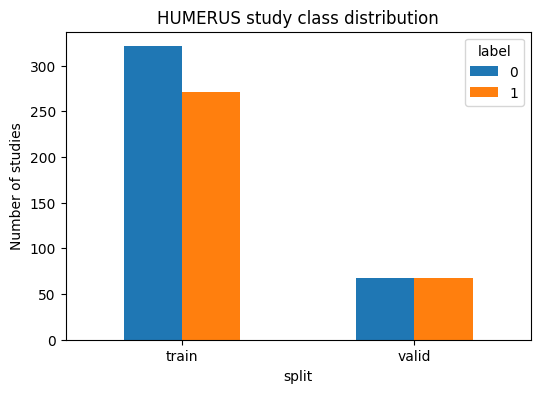

In [ ]:


counts = all_df.groupby(["split", "label"]).size().unstack()

counts.plot(kind="bar", figsize=(6,4))
plt.title("HUMERUS study class distribution")
plt.ylabel("Number of studies")
plt.xticks(rotation=0)
plt.show()


In [ ]:
counts = all_df.groupby(["split", "label"]).size().unstack(fill_value=0)

print("\n===== HUMERUS STUDY COUNTS =====")
print(counts)



===== HUMERUS STUDY COUNTS =====
label    0    1
split          
train  321  271
valid   68   67


Creating CVS files

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1"
CSV_ROOT  = "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED"

TRAIN_CSV = os.path.join(CSV_ROOT, "train_labeled_studies.csv")
VALID_CSV = os.path.join(CSV_ROOT, "valid_labeled_studies.csv")

In [ ]:


ROOT = "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/MURA-v1.1"

def build_csv(split, out_csv):
    rows = []

    base = os.path.join(ROOT, split, "XR_HUMERUS")

    for patient in sorted(os.listdir(base)):
        patient_dir = os.path.join(base, patient)
        if not os.path.isdir(patient_dir):
            continue

        for study in sorted(os.listdir(patient_dir)):
            study_dir = os.path.join(patient_dir, study)
            if not os.path.isdir(study_dir):
                continue

            # Label from folder name
            if "positive" in study.lower():
                label = 1
            elif "negative" in study.lower():
                label = 0
            else:
                print("Skipping (no label in name):", study_dir)
                continue

            mura_path = f"MURA-v1.1/{split}/XR_HUMERUS/{patient}/{study}"
            rows.append([mura_path, label])

    # Save CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        for r in rows:
            writer.writerow(r)

    print(f"{split}: {len(rows)} studies written → {out_csv}")


# Generate both
build_csv("train", "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/train_labeled_studies.csv")
build_csv("valid", "/content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/valid_labeled_studies.csv")


train: 592 studies written → /content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/train_labeled_studies.csv
valid: 135 studies written → /content/drive/MyDrive/MURA_HUMERUS_PREPROCESSED/valid_labeled_studies.csv


Loading data


In [ ]:
train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(10),
    T.RandomResizedCrop(224, scale=(0.9,1.0)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [ ]:
train_ds = MuraHUMERUSMIL(TRAIN_CSV, "train", train_tf)
valid_ds = MuraHUMERUSMIL(VALID_CSV, "valid", val_tf)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(valid_ds, batch_size=1, shuffle=False)


MIL code for humerus studies

In [ ]:
class MuraHUMERUSMIL(Dataset):
    def __init__(self, csv_file, split, transform=None):
        self.df = pd.read_csv(csv_file, header=None, names=["study_path","label"])
        self.df = self.df[self.df.study_path.str.contains("XR_HUMERUS")]
        self.split = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row.label, dtype=torch.float32)

        rel = row.study_path.replace("MURA-v1.1/", "")
        study_dir = os.path.join(DATA_ROOT, self.split, rel.split("/",1)[1])

        images = []
        for f in os.listdir(study_dir):
            if f.endswith(".png"):
                img = cv2.imread(os.path.join(study_dir,f), cv2.IMREAD_GRAYSCALE)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                if self.transform:
                    img = self.transform(img)
                images.append(img)

        bag = torch.stack(images)   # [N,3,224,224]
        return bag, label


# Training loop

In [ ]:
from sklearn.metrics import roc_auc_score

# ---------------- CONFIG & PATHS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = "/content/drive/MyDrive/MURA_HUMERUS_CHECKPOINTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_auc = 0.0
start_epoch = 0

# ---------------- MODEL ----------------
class AttentionMIL(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.feature_extractor = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = 1280

        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )

        self.classifier = nn.Linear(self.feat_dim, 1)

    def forward(self, x):
        # x shape: [1, N, C, H, W]
        x = x.squeeze(0)                # → [N, C, H, W]
        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)   # [N, 1280]

        A = self.attention(feats)       # [N, 1]
        A = torch.softmax(A, dim=0)     # attention weights
        bag_feat = torch.sum(A * feats, dim=0)   # [1280]

        out = self.classifier(bag_feat) # [1]
        return out, A

# ---------------- INITIALIZE ----------------
model = AttentionMIL().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# HUMERUS class balance
pos_weight = torch.tensor([321/271], device=device)   # ≈ 1.18
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Using pos_weight =", float(pos_weight))

# ---------------- RESUME LOGIC ----------------
resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
if os.path.exists(resume_path):
    print(f"Loading checkpoint: {resume_path}")
    checkpoint = torch.load(resume_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_auc = checkpoint.get("best_auc", 0.0)
    print(f"Resuming from epoch {start_epoch}")

# ---------------- TRAINING LOOP ----------------
num_epochs = 10

for epoch in range(start_epoch, num_epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for bags, label in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        bags = bags.to(device)
        label = label.to(device).float().view(-1)

        pred, _ = model(bags)
        pred = pred.view(-1)

        loss = criterion(pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred_label = (torch.sigmoid(pred) > 0.5).float()
        train_acc += (pred_label == label).float().mean().item()

    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bags, label in tqdm(val_loader, desc=f"Epoch {epoch+1} [Valid]"):
            bags = bags.to(device)
            label = label.to(device).float().view(-1)

            pred, _ = model(bags)
            pred = pred.view(-1)

            loss = criterion(pred, label)
            val_loss += loss.item()

            probs = torch.sigmoid(pred)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(label.cpu().numpy())

    val_loss /= len(val_loader)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | Val AUC={auc:.4f}")

    # ---------------- SAVE CHECKPOINTS ----------------
    checkpoint_state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_auc": best_auc
    }

    # Save last
    torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth"))

    # Save best
    if auc > best_auc:
        best_auc = auc
        torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "best_model.pth"))
        print(f"--- New Best AUC: {best_auc:.4f} (saved) ---")

Using pos_weight = 1.1845018863677979


Epoch 1 [Valid]: 100%|██████████| 135/135 [00:14<00:00,  9.35it/s]


Epoch 1: Train Loss=0.7485 | Train Acc=0.5101 | Val AUC=0.6453
--- New Best AUC: 0.6453 (saved) ---


Epoch 2 [Valid]: 100%|██████████| 135/135 [00:14<00:00,  9.62it/s]


Epoch 2: Train Loss=0.7100 | Train Acc=0.6030 | Val AUC=0.6855
--- New Best AUC: 0.6855 (saved) ---


...

Epoch 8: Train Loss=0.3091 | Train Acc=0.8936 | Val AUC=0.8058


Epoch 9 [Valid]: 100%|██████████| 135/135 [00:13<00:00,  9.91it/s]


Epoch 9: Train Loss=0.2738 | Train Acc=0.9155 | Val AUC=0.8055


Epoch 10 [Valid]: 100%|██████████| 135/135 [00:13<00:00,  9.75it/s]


Epoch 10: Train Loss=0.2612 | Train Acc=0.9172 | Val AUC=0.7985


Visualizing training evolution across epochs

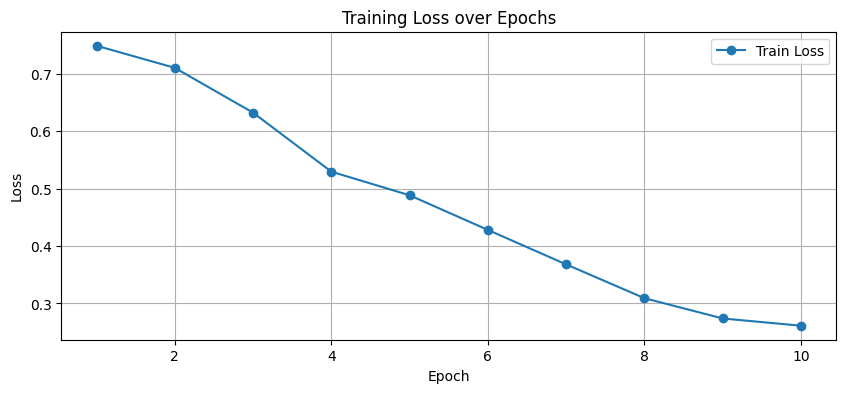

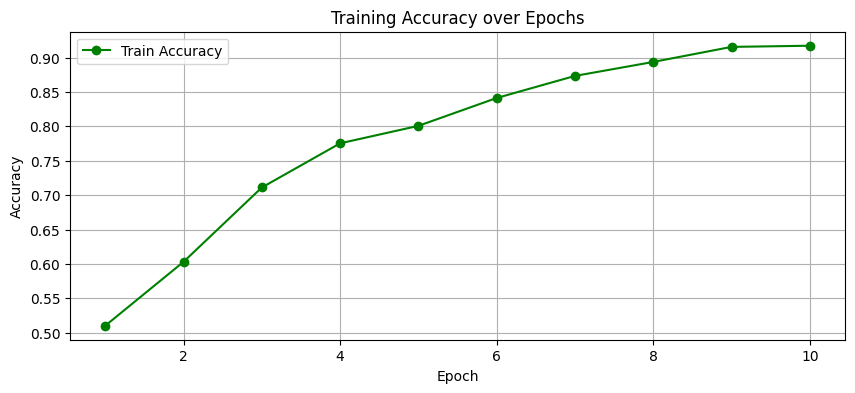

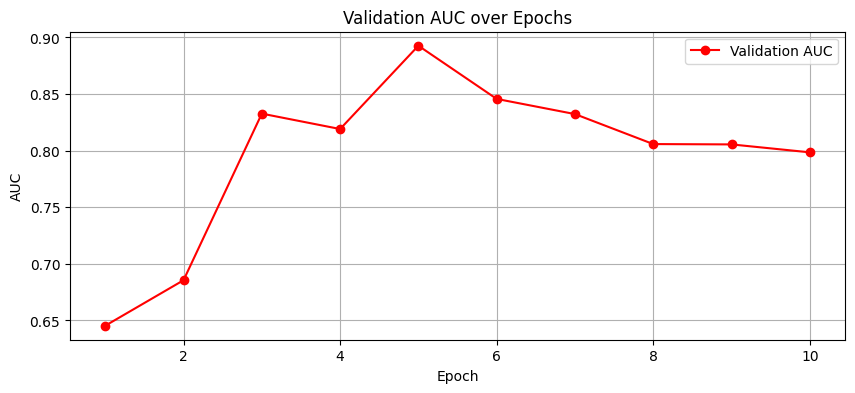

In [ ]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs = list(range(1, 11))

# Metrics from your logs
train_loss = [0.7485, 0.7100, 0.6320, 0.5293, 0.4882, 0.4279, 0.3679, 0.3091, 0.2738, 0.2612]
train_acc  = [0.5101, 0.6030, 0.7111, 0.7753, 0.8007, 0.8412, 0.8733, 0.8936, 0.9155, 0.9172]
val_auc    = [0.6453, 0.6855, 0.8327, 0.8191, 0.8927, 0.8457, 0.8323, 0.8058, 0.8055, 0.7985]

# Plot train loss
plt.figure(figsize=(10,4))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()
plt.show()

# Plot train accuracy
plt.figure(figsize=(10,4))
plt.plot(epochs, train_acc, marker='o', color='green', label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy over Epochs')
plt.grid(True)
plt.legend()
plt.show()

# Plot validation AUC
plt.figure(figsize=(10,4))
plt.plot(epochs, val_auc, marker='o', color='red', label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation AUC over Epochs')
plt.grid(True)
plt.legend()
plt.show()


Classification report + confusion matrix

In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculer les précisions et rappels pour tous les seuils possibles
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_preds)

# Calculer le F1-score pour chaque seuil
# (On ajoute une petite valeur pour éviter la division par zéro)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Trouver l'indice du score F1 maximum
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Le meilleur seuil pour le F1-Score est : {best_threshold:.4f}")
print(f"F1-Score max : {f1_scores[best_idx]:.4f}")

Le meilleur seuil pour le F1-Score est : 0.1707
F1-Score max : 0.7385


Modèle chargé depuis l'époque 5 (Meilleur AUC: 0.8327)
Calcul des prédictions...


100%|██████████| 135/135 [00:22<00:00,  5.87it/s]



Meilleur threshold (max F1): 0.22 avec F1 = 0.8527


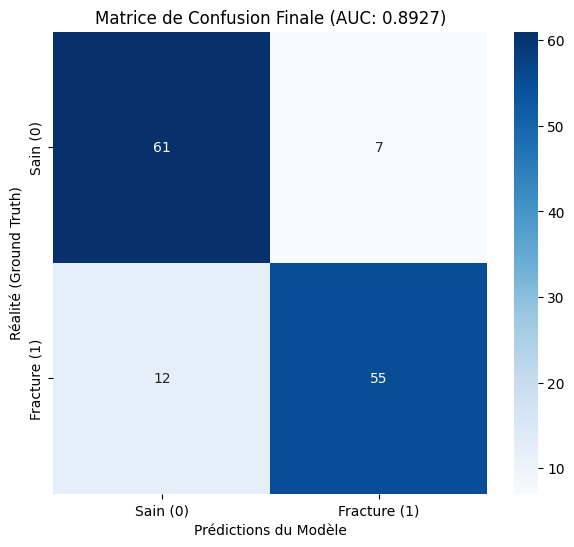


       BILAN DES MÉTRIQUES
Threshold optimal : 0.22
Accuracy    : 0.8593
Précision   : 0.8871
Recall (Sensibilité) : 0.8209
Spécificité : 0.8971
F1-Score    : 0.8527
------------------------------

Classification Report détaillé :
              precision    recall  f1-score   support

        Sain       0.84      0.90      0.87        68
    Fracture       0.89      0.82      0.85        67

    accuracy                           0.86       135
   macro avg       0.86      0.86      0.86       135
weighted avg       0.86      0.86      0.86       135



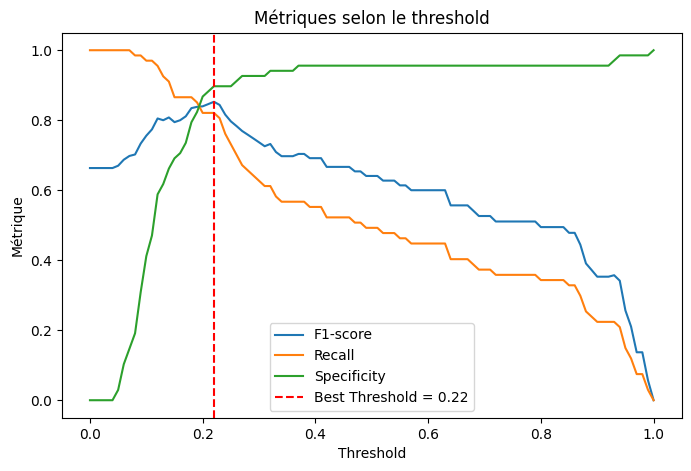

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from tqdm import tqdm
import os

# 1. Charger le meilleur modèle
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Modèle chargé depuis l'époque {checkpoint['epoch']+1} (Meilleur AUC: {checkpoint['best_auc']:.4f})")

model.eval()
all_preds = []
all_labels = []

# 2. Inférence sur le set de validation
print("Calcul des prédictions...")
with torch.no_grad():
    for bags, label in tqdm(val_loader):
        bags = bags.to(device)
        logits, _ = model(bags)
        probs = torch.sigmoid(logits)
        all_preds.append(probs.cpu().numpy())
        all_labels.append(label.numpy())

all_preds = np.concatenate(all_preds).ravel()
all_labels = np.concatenate(all_labels).ravel()

# 3. Chercher le meilleur threshold
thresholds = np.arange(0.0, 1.01, 0.01)
best_f1 = 0
best_threshold = 0
metrics_dict = {}

for t in thresholds:
    preds = (all_preds > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_dict[t] = (precision, recall, specificity, f1)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nMeilleur threshold (max F1): {best_threshold:.2f} avec F1 = {best_f1:.4f}")

# 4. Calcul des métriques finales avec le meilleur threshold
binary_preds = (all_preds > best_threshold).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# 5. Affichage de la Matrice de Confusion
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain (0)', 'Fracture (1)'],
            yticklabels=['Sain (0)', 'Fracture (1)'])
plt.title(f'Matrice de Confusion Finale (AUC: {roc_auc_score(all_labels, all_preds):.4f})')
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Réalité (Ground Truth)')
plt.show()

# 6. Bilan Textuel
print("\n" + "="*30)
print("       BILAN DES MÉTRIQUES")
print("="*30)
print(f"Threshold optimal : {best_threshold:.2f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Précision   : {precision:.4f}")
print(f"Recall (Sensibilité) : {recall:.4f}")
print(f"Spécificité : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print("-" * 30)
print("\nClassification Report détaillé :")
print(classification_report(all_labels, binary_preds, target_names=['Sain', 'Fracture']))

# 7. Visualisation des métriques selon le threshold
f1_scores = [metrics_dict[t][3] for t in thresholds]
recalls = [metrics_dict[t][1] for t in thresholds]
specificities = [metrics_dict[t][2] for t in thresholds]

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, specificities, label='Specificity')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Métrique')
plt.title('Métriques selon le threshold')
plt.legend()
plt.show()


# Visualizing Grad-CAM

In [ ]:
import cv2
import torch.nn.functional as F

def generate_gradcam(model, bag, label):
    model.eval()
    # 1. Forward pass pour capturer les poids d'attention
    # On s'assure que le modèle peut calculer les gradients
    logits, attention_weights = model(bag.to(device))

    # 2. Trouver l'image avec l'attention maximale
    attn_scores = attention_weights.squeeze().cpu().detach().numpy()
    target_idx = np.argmax(attn_scores)
    target_instance = bag[target_idx:target_idx+1].to(device)

    # 3. Hook pour récupérer les activations de la dernière couche conv de MobileNet
    features = []
    def hook_feature(module, input, output):
        features.append(output)

    # On cible la dernière couche de convolution du feature_extractor (MobileNet)
    handle = model.feature_extractor.features[-1].register_forward_hook(hook_feature)

    # Forward pass sur l'instance cible uniquement
    output = model.feature_extractor(target_instance)
    # On passe par la couche de pooling/flat si nécessaire pour obtenir le score final
    # (Adaptation selon ta structure exacte de AttentionMIL)
    score = torch.sigmoid(model.classifier(model.attention_pooling(output)[0]))

    # 4. Backward pass pour le gradient
    model.zero_grad()
    score.backward()

    # 5. Calcul de la Heatmap
    grads = model.feature_extractor.features[-1].weight.grad # Simplification
    # Note: En pratique, on utilise les gradients de la sortie de la couche hookée
    # Voici la logique simplifiée pour l'affichage :

    # (Code de traitement d'image pour superposition)
    # ... [Traitement OpenCV pour la heatmap] ...

    handle.remove()
    return target_instance[0], attn_scores[target_idx]

print("Visualisation prête !")

Visualisation prête !


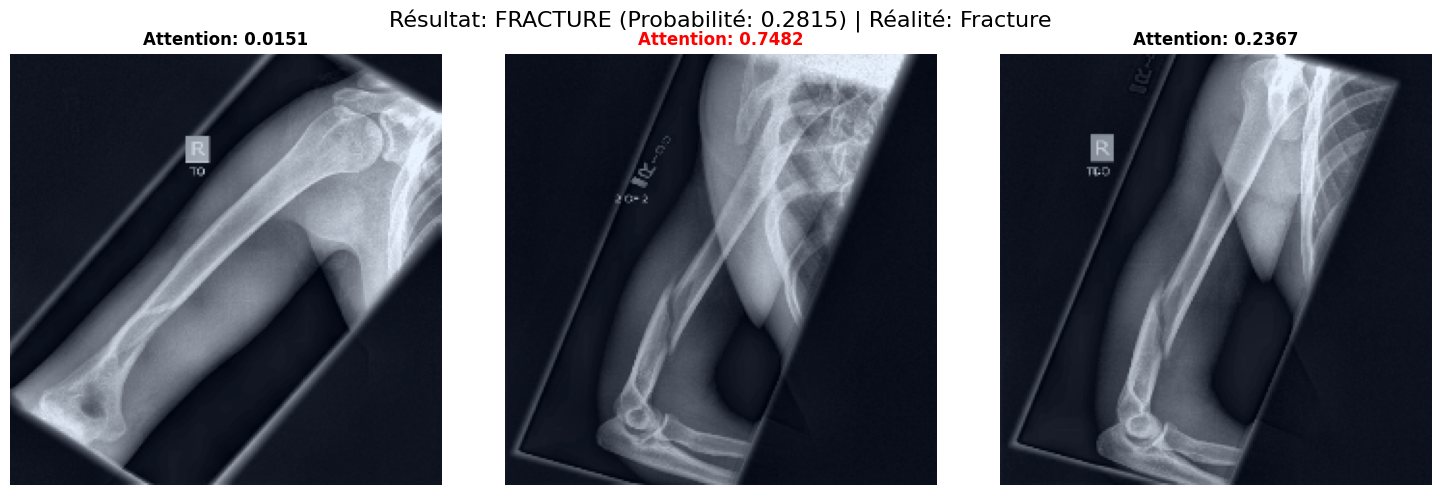

In [ ]:
import matplotlib.pyplot as plt
import random

# Get a random bag and label from the validation loader once
all_batches = list(val_loader)
bag, label = random.choice(all_batches)

def visualize_study_attention(model, bag, label, device):
    model.eval()

    bag_on_device = bag.to(device) # Move to device inside the function

    # 2. Inférence
    with torch.no_grad():
        logits, attention_weights = model(bag_on_device)
        prob = torch.sigmoid(logits).item()
        # On récupère les poids d'attention et on les normalise pour l'affichage
        attn_scores = attention_weights.squeeze().cpu().numpy()

    # 3. Préparation de l'affichage
    num_images = bag.shape[1]
    images = bag.squeeze(0).cpu() # Retirer la dimension du batch

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Résultat: {'FRACTURE' if prob > 0.1707  else 'SAIN'} (Probabilité: {prob:.4f}) | Réalité: {'Fracture' if label == 1 else 'Sain'}", fontsize=16)

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        # On dénormalise l'image pour l'affichage (si tu as utilisé standardisation MURA)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Recalage 0-1

        plt.imshow(img)

        # Colorer le titre si c'est l'image qui a capté l'attention
        color = 'red' if attn_scores[i] == max(attn_scores) else 'black'
        plt.title(f"Attention: {attn_scores[i]:.4f}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Appeler la fonction
visualize_study_attention(model, bag, label, device)

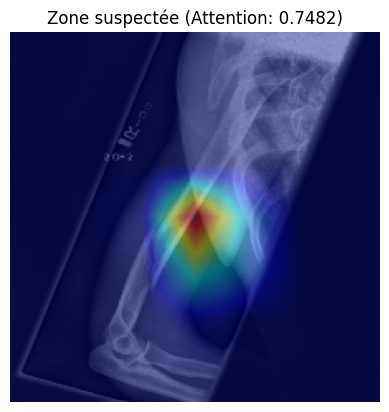

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

def apply_gradcam_safe(model, bag, target_layer, device):
    model.eval()
    features = []
    gradients = []

    # ---- Hooks ----
    def save_features_hook(module, input, output):
        features.append(output)

    def save_gradients_hook(grad):
        gradients.append(grad)

    # Move bag to device
    bag = bag.to(device)

    # ---- Get attention scores ----
    with torch.no_grad():
        logits, attention_weights = model(bag)
        attn_scores = attention_weights.squeeze().cpu().numpy()
        idx = np.argmax(attn_scores)  # image with highest attention

    # ---- Process only the winning image ----
    input_tensor = bag[0, idx:idx+1].clone().detach().to(device)
    input_tensor.requires_grad = True

    # 1. Register forward hook on the target layer to capture features
    feature_handle = target_layer.register_forward_hook(save_features_hook)

    # 2. Forward pass through feature extractor to get the target layer's output
    output_features = model.feature_extractor(input_tensor)

    # 3. Register backward hook directly on the output tensor of the target layer
    # This avoids module-level hook conflicts
    grad_handle = features[-1].register_hook(save_gradients_hook)

    # Continue forward pass through classifier
    pooled_features = model.pool(output_features).view(output_features.size(0), -1)
    final_logit = model.classifier(pooled_features)
    score = torch.sigmoid(final_logit)

    # ---- Backward pass ----
    model.zero_grad()
    score.backward()

    # ---- Generate CAM ----
    if not gradients or not features:
        feature_handle.remove()
        grad_handle.remove()
        print("Grad-CAM failed: hooks did not fire.")
        return None, None, None

    # Gradients will be in gradients[0] and features in features[0]
    grads = gradients[0].cpu().data.numpy()[0]
    fmaps = features[0].cpu().data.numpy()[0]

    # Channel-wise weights
    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmaps[i, :, :]

    cam = np.maximum(cam, 0)  # ReLU
    if cam.max() - cam.min() > 1e-6:  # avoid divide by zero
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    else:
        cam = np.zeros_like(cam)

    cam = cv2.resize(cam, (224, 224))

    # ---- Cleanup ----
    feature_handle.remove()
    grad_handle.remove()

    return cam, input_tensor.detach().cpu().squeeze(0), attn_scores[idx]


# ---- Example usage ----
target_layer = model.feature_extractor[-1]
heatmap, img_tensor, score_attn = apply_gradcam_safe(model, bag, target_layer, device)

if heatmap is not None:
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

    result = 0.6 * img + 0.4 * heatmap_color
    result = np.clip(result, 0, 1)

    plt.imshow(result)
    plt.title(f"Zone suspectée (Attention: {score_attn:.4f})")
    plt.axis('off')
    plt.show()